### Simulación y Diagnóstico OLS
- La diferencia entre el parámetro poblacional y el estimador muestral, cómo se comporta la función de costo y cómo validar los supuestos críticos de Gauss-Markov mediante gráficos de diagnóstico.

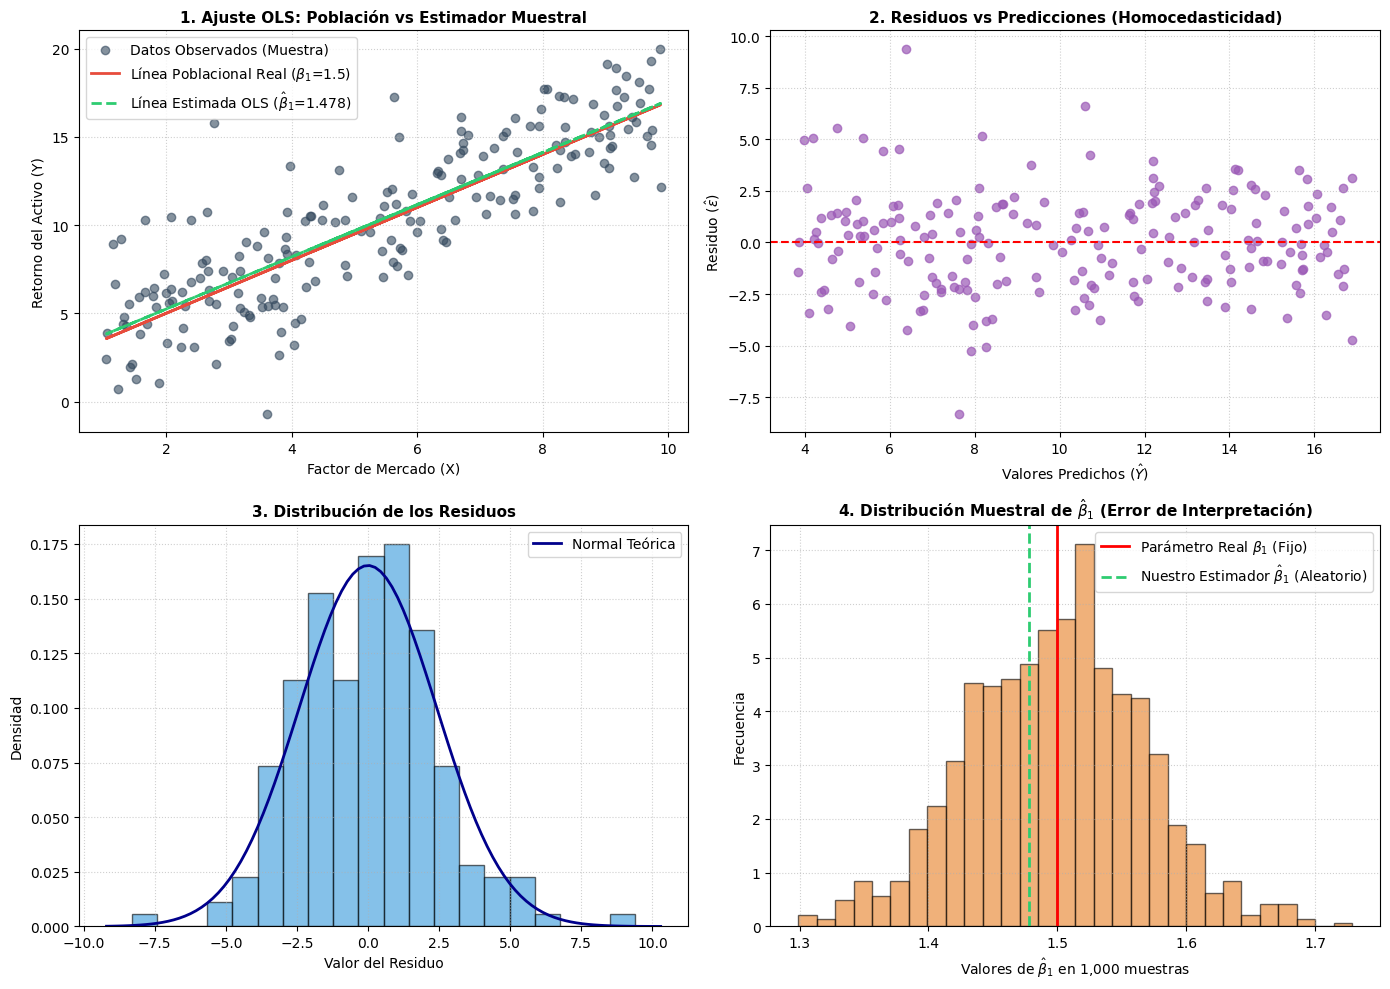

=================== REPORTE ACADÉMICO FRM PART 1 ===================
Cálculo Manual por Momentos (Cov/Var): Pendiente = 1.4783
Estimador OLS de la Pendiente (beta_1_hat): 1.4783
Error Estándar del Estimador (SE):          0.0649
Estadístico t (H0: beta_1 = 0):            22.7951
P-Valor:                                    2.8755e-57
R-cuadrado del modelo:                      0.7241


In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import scipy.stats as stats

# Definir una semilla para la replicabilidad del experimento (FRM Quantitative Section)
np.random.seed(42)

# =============================================================================
# 1. EL MODELO POBLACIONAL REAL (Oculto en el mercado real)
# Y = beta_0 + beta_1 * X + epsilon
# =============================================================================
N = 200
BETA_0_TRUE = 2.0   # Intercepto poblacional (Retorno base del activo cuando el mercado no se mueve)
BETA_1_TRUE = 1.5   # Pendiente poblacional (Beta real del activo / Sensibilidad frente al mercado)

# Supuesto: X tiene variación (Var(X) > 0). No hay colinealidad perfecta.
X = np.random.uniform(1, 10, N)

# Supuesto: Homocedasticidad (Varianza constante) y Exogeneidad E[epsilon|X] = 0
sigma_error = 2.5
epsilon = np.random.normal(0, sigma_error, N)

# Generación de la variable dependiente Y
Y = BETA_0_TRUE + BETA_1_TRUE * X + epsilon

# =============================================================================
# 2. ESTIMACIÓN MECÁNICA POR MÍNIMOS CUADRADOS ORDINARIOS (OLS)
# =============================================================================
# Cálculo manual basado en momentos bivariados para contrastar con OLS
cov_xy = np.cov(X, Y)[0, 1]
var_x = np.var(X, ddof=1)
beta_1_manual = cov_xy / var_x
beta_0_manual = np.mean(Y) - beta_1_manual * np.mean(X)

# Estimación formal usando Statsmodels (Función de costo que minimiza RSS)
X_with_constant = sm.add_constant(X) # Agrega el vector de 1s para estimar beta_0
model = sm.OLS(Y, X_with_constant)
results = model.fit()

# Extraer estimadores muestrales y sus errores estándar
beta_0_hat = results.params[0]
beta_1_hat = results.params[1]
se_beta_1 = results.bse[1]
t_stat_beta_1 = results.tvalues[1]
p_val_beta_1 = results.pvalues[1]

# =============================================================================
# 3. VISUALIZACIÓN Y DIAGNÓSTICO DE SUPUESTOS
# =============================================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- GRÁFICO 1: Línea de Mejor Ajuste y Error de Interpretación ---
axes[0, 0].scatter(X, Y, color='#34495e', alpha=0.6, label='Datos Observados (Muestra)')
axes[0, 0].plot(X, BETA_0_TRUE + BETA_1_TRUE * X, color='#e74c3c', linewidth=2, label=f'Línea Poblacional Real ($\\beta_1$={BETA_1_TRUE})')
axes[0, 0].plot(X, results.fittedvalues, color='#2ecc71', linewidth=2, linestyle='--', label=f'Línea Estimada OLS ($\\hat{{\\beta}}_1$={beta_1_hat:.3f})')
axes[0, 0].set_title('1. Ajuste OLS: Población vs Estimador Muestral', fontsize=11, fontweight='bold')
axes[0, 0].set_xlabel('Factor de Mercado (X)')
axes[0, 0].set_ylabel('Retorno del Activo (Y)')
axes[0, 0].legend()
axes[0, 0].grid(True, linestyle=':', alpha=0.6)

# --- GRÁFICO 2: Análisis de Residuos vs X (Verificación de Homocedasticidad) ---
residuos = results.resid
axes[0, 1].scatter(results.fittedvalues, residuos, color='#9b59b6', alpha=0.7)
axes[0, 1].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[0, 1].set_title('2. Residuos vs Predicciones (Homocedasticidad)', fontsize=11, fontweight='bold')
axes[0, 1].set_xlabel('Valores Predichos ($\\hat{Y}$)')
axes[0, 1].set_ylabel('Residuo ($\\hat{\\epsilon}$)')
axes[0, 1].grid(True, linestyle=':', alpha=0.6)

# --- GRÁFICO 3: Distribución de los Errores (Prueba de Inferencia Estadística) ---
axes[1, 0].hist(residuos, bins=20, density=True, color='#3498db', alpha=0.6, edgecolor='black')
# Superponer curva normal teórica
xmin, xmax = axes[1, 0].get_xlim()
x_axis = np.linspace(xmin, xmax, 100)
axes[1, 0].plot(x_axis, stats.norm.pdf(x_axis, 0, np.std(residuos)), color='darkblue', linewidth=2, label='Normal Teórica')
axes[1, 0].set_title('3. Distribución de los Residuos', fontsize=11, fontweight='bold')
axes[1, 0].set_xlabel('Valor del Residuo')
axes[1, 0].set_ylabel('Densidad')
axes[1, 0].legend()
axes[1, 0].grid(True, linestyle=':', alpha=0.6)

# --- GRÁFICO 4: El Error del Estudiante (Distribución Muestral del Estimador) ---
# Simulamos 1000 muestras diferentes para demostrar que beta_hat es una VARIABLE ALEATORIA
beta_1_simulados = []
for _ in range(1000):
    eps_sim = np.random.normal(0, sigma_error, N)
    Y_sim = BETA_0_TRUE + BETA_1_TRUE * X + eps_sim
    model_sim = sm.OLS(Y_sim, X_with_constant).fit()
    beta_1_simulados.append(model_sim.params[1])

axes[1, 1].hist(beta_1_simulados, bins=30, color='#e67e22', alpha=0.6, edgecolor='black', density=True)
axes[1, 1].axvline(BETA_1_TRUE, color='red', linewidth=2, label=r'Parámetro Real $\beta_1$ (Fijo)')
axes[1, 1].axvline(beta_1_hat, color='#2ecc71', linewidth=2, linestyle='--', label=r'Nuestro Estimador $\hat{\beta}_1$ (Aleatorio)')
axes[1, 1].set_title(r'4. Distribución Muestral de $\hat{\beta}_1$ (Error de Interpretación)', fontsize=11, fontweight='bold')
axes[1, 1].set_xlabel(r'Valores de $\hat{\beta}_1$ en 1,000 muestras')
axes[1, 1].set_ylabel('Frecuencia')
axes[1, 1].legend()
axes[1, 1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# =============================================================================
# 4. REPORTE CUANTITATIVO DE REPASO (Métricas Clave de Examen)
# =============================================================================
print("=================== REPORTE ACADÉMICO FRM PART 1 ===================")
print(f"Cálculo Manual por Momentos (Cov/Var): Pendiente = {beta_1_manual:.4f}")
print(f"Estimador OLS de la Pendiente (beta_1_hat): {beta_1_hat:.4f}")
print(f"Error Estándar del Estimador (SE):          {se_beta_1:.4f}")
print(f"Estadístico t (H0: beta_1 = 0):            {t_stat_beta_1:.4f}")
print(f"P-Valor:                                    {p_val_beta_1:.4e}")
print(f"R-cuadrado del modelo:                      {results.rsquared:.4f}")
print("====================================================================")


In [2]:
from statsmodels.stats.stattools import jarque_bera

# Aplicar la prueba de Jarque-Bera sobre los residuos calculados previamente
jb_score, p_value, skew, kurtosis = jarque_bera(residuos)

print("--- PRUEBA DE NORMALIDAD DE JARQUE-BERA ---")
print(f"Estadístico JB: {jb_score:.4f}")
print(f"P-Valor:         {p_value:.4f}")
print(f"Asimetría (Skewness) de los residuos: {skew:.4f}  (Objetivo Normal = 0)")
print(f"Curtosis de los residuos:            {kurtosis:.4f}  (Objetivo Normal = 3)")

if p_value < 0.05:
    print("\nResultado: RECHAZAMOS H0. Los residuos NO siguen una distribución normal.")
else:
    print("\nResultado: NO RECHAZAMOS H0. Confirmado, los residuos SI se distribuyen normalmente.")


--- PRUEBA DE NORMALIDAD DE JARQUE-BERA ---
Estadístico JB: 9.1994
P-Valor:         0.0101
Asimetría (Skewness) de los residuos: 0.2312  (Objetivo Normal = 0)
Curtosis de los residuos:            3.9434  (Objetivo Normal = 3)

Resultado: RECHAZAMOS H0. Los residuos NO siguen una distribución normal.


In [3]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import scipy.stats as stats
from statsmodels.stats.stattools import jarque_bera

# 1. GENERACIÓN DE DATOS CON ERRORES INTENCIONALMENTE NO NORMALES
np.random.seed(42)
N = 200
X = np.random.uniform(1, 10, N)

# Generamos errores usando una distribución 't de Student' con solo 3 grados de libertad.
# Esto asegura colas extremadamente pesadas y picos que violan la normalidad (Falla JB).
epsilon_no_normal = np.random.standard_t(df=3, size=N) * 1.5

BETA_0_TRUE = 2.0
BETA_1_TRUE = 1.5  # Existe un efecto real en la población

Y = BETA_0_TRUE + BETA_1_TRUE * X + epsilon_no_normal

# 2. AJUSTE DEL MODELO OLS
X_with_constant = sm.add_constant(X)
model = sm.OLS(Y, X_with_constant)
results = model.fit()

# 3. VERIFICACIÓN DE JARQUE-BERA
jb_score, p_value_jb, skew, kurtosis = jarque_bera(results.resid)

# 4. EXTRACCIÓN Y CÁLCULO MANUAL DEL ESTADÍSTICO T PARA LA PENDIENTE (beta_1)
beta_1_hat = results.params[1]     # Nuestro coeficiente estimado
se_beta_1 = results.bse[1]         # Error estándar del coeficiente (usa la varianza de los residuos)

# El estadístico t bajo H0: beta_1 = 0 se calcula: (estimador - valor_H0) / SE
t_estadistico_manual = (beta_1_hat - 0) / se_beta_1
p_valor_t = results.pvalues[1]     # P-valor de dos colas para la prueba t

# Valor crítico de una distribución t para el 95% de confianza (Alpha = 0.05) con N-2 grados de libertad
grados_libertad = N - 2
valor_critico = stats.t.ppf(1 - 0.05/2, df=grados_libertad)

# 5. REPORTE EJECUTIVO DE RESULTADOS
print("=================== RESULTADOS DE CONTRASTE DE HIPÓTESIS ===================")
print(f"1. PRUEBA DE NORMALIDAD (Jarque-Bera):")
print(f"   - P-Valor de JB: {p_value_jb:.4e}")
print(f"   - Conclusión JB: Rechazamos H0 (Los residuos NO son normales de forma contundente)")
print(f"   - Curtosis observada: {kurtosis:.4f} (Muy superior al 3.0 de una normal)")

print(f"\n2. PRUEBA DE INFERENCIA (Invocando TLC por muestra N={N}):")
print(f"   - Coeficiente estimado (beta_1_hat): {beta_1_hat:.4f}")
print(f"   - Error Estándar (SE):              {se_beta_1:.4f}")
print(f"   - Estadístico t calculado:           {t_estadistico_manual:.4f}")
print(f"   - Valor Crítico de la tabla t (95%): ±{valor_critico:.4f}")
print(f"   - P-Valor de la prueba t:           {p_valor_t:.4e}")

print("\n3. DECISIÓN FINAL SOBRE LA COBERTURA / EFECTO:")
if abs(t_estadistico_manual) > valor_critico:
    print("   -> RECHAZAMOS H0. A pesar de la no-normalidad de los residuos,")
    print("      el TLC nos garantiza que el estadístico t es válido.")
    print("      Concluimos que X tiene un efecto lineal estadísticamente significativo sobre Y.")
else:
    print("   -> NO RECHAZAMOS H0. No hay suficiente evidencia para afirmar un efecto lineal.")
print("============================================================================")


=================== RESULTADOS DE CONTRASTE DE HIPÓTESIS ===================
1. PRUEBA DE NORMALIDAD (Jarque-Bera):
   - P-Valor de JB: 1.6343e-10
   - Conclusión JB: Rechazamos H0 (Los residuos NO son normales de forma contundente)
   - Curtosis observada: 5.3016 (Muy superior al 3.0 de una normal)

2. PRUEBA DE INFERENCIA (Invocando TLC por muestra N=200):
   - Coeficiente estimado (beta_1_hat): 1.4766
   - Error Estándar (SE):              0.0563
   - Estadístico t calculado:           26.2166
   - Valor Crítico de la tabla t (95%): ±1.9720
   - P-Valor de la prueba t:           2.5994e-66

3. DECISIÓN FINAL SOBRE LA COBERTURA / EFECTO:
   -> RECHAZAMOS H0. A pesar de la no-normalidad de los residuos,
      el TLC nos garantiza que el estadístico t es válido.
      Concluimos que X tiene un efecto lineal estadísticamente significativo sobre Y.
